# AI Job Market Analysis
## Comprehensive Data Science & Machine Learning Career Insights

**Author:** Sitt Min Thar
**Date:** March 2026
**Purpose:** Analyze trends, opportunities, and requirements in the AI job market

This notebook provides a deep dive into the current state of the AI job market, examining key trends, salary patterns, skill demands, and growth opportunities across different regions and company sizes.

In [1]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
%matplotlib inline

In [2]:
# Load the dataset
df = pd.read_csv('AI Job Market Dataset.csv')

# Display basic information about the dataset
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 rows:")
df.head()

Dataset Shape: (10345, 19)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   job_id                10345 non-null  int64
 1   job_title             10345 non-null  str  
 2   company_size          10345 non-null  str  
 3   company_industry      10345 non-null  str  
 4   country               10345 non-null  str  
 5   remote_type           10345 non-null  str  
 6   experience_level      10345 non-null  str  
 7   years_experience      10345 non-null  int64
 8   education_level       10345 non-null  str  
 9   skills_python         10345 non-null  int64
 10  skills_sql            10345 non-null  int64
 11  skills_ml             10345 non-null  int64
 12  skills_deep_learning  10345 non-null  int64
 13  skills_cloud          10345 non-null  int64
 14  salary                10345 non-null  int64
 15  job_posting_month     

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
0,1,AI Engineer,Startup,Retail,Canada,Remote,Senior,2,Master,0,0,0,1,0,158322,6,2024,Low,4
1,2,Machine Learning Engineer,MNC,Technology,Australia,Hybrid,Mid,0,Bachelor,1,1,1,0,1,163666,11,2026,High,9
2,3,Machine Learning Engineer,MNC,Technology,Germany,Onsite,Mid,14,Master,1,0,1,0,1,158556,3,2026,High,9
3,4,Business Analyst,Startup,Healthcare,Germany,Remote,Mid,9,Master,0,1,0,1,1,95775,3,2025,High,7
4,5,Data Scientist,MNC,Healthcare,Germany,Hybrid,Mid,5,Master,1,1,1,0,0,111873,12,2021,Low,2


In [3]:
# Basic statistics of the dataset
df.describe(include='all')

,job_id,job_title,company_size,company_industry,country,remote_type,experience_level,years_experience,education_level,skills_python,skills_sql,skills_ml,skills_deep_learning,skills_cloud,salary,job_posting_month,job_posting_year,hiring_urgency,job_openings
count,10345.000000,10345,10345,10345,10345,10345,10345,10345.000000,10345,10345.000000,10345.000000,10345.000000,10345.000000,10345.000000,10345.00000,10345.000000,10345.000000,10345,10345.00000
unique,NaN,6,4,6,7,3,3,NaN,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,NaN
top,NaN,Business Analyst,Startup,Technology,Germany,Remote,Entry,NaN,Master,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,High,NaN
freq,NaN,1773,2656,1787,1498,3513,3513,NaN,3529,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5195,NaN
mean,5173.000000,NaN,NaN,NaN,NaN,NaN,NaN,6.950507,NaN,0.493088,0.503045,0.507878,0.498018,0.511455,113438.22726,6.502465,2023.000387,NaN,5.00406
std,2986.488601,NaN,NaN,NaN,NaN,NaN,NaN,4.320054,NaN,0.499976,0.500015,0.499962,0.500020,0.499893,31389.20106,3.473441,1.996856,NaN,2.58382
min,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,45083.00000,1.000000,2020.000000,NaN,1.00000
25%,2587.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,89715.00000,4.000000,2021.000000,NaN,3.00000
50%,5173.000000,NaN,NaN,NaN,NaN,NaN,NaN,7.000000,NaN,0.000000,1.000000,1.000000,0.000000,1.000000,113082.00000,6.000000,2023.000000,NaN,5.00000
75%,7759.000000,NaN,NaN,NaN,NaN,NaN,NaN,11.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,134894.00000,10.000000,2025.000000,NaN,7.00000


In [4]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values[missing_values > 0])

Missing Values:
Series([], dtype: int64)


# 1. Dataset Overview & Key Metrics

In [5]:
# Key metrics
total_jobs = len(df)
unique_job_titles = df['job_title'].nunique()
unique_countries = df['country'].nunique()
avg_salary = df['salary'].mean()
median_salary = df['salary'].median()

print(f"Total Jobs in Dataset: {total_jobs:,}")
print(f"Unique Job Titles: {unique_job_titles}")
print(f"Countries Represented: {unique_countries}")
print(f"Average Salary: ${avg_salary:,.2f}")
print(f"Median Salary: ${median_salary:,.2f}")

# Most common job titles
top_job_titles = df['job_title'].value_counts().head(10)
print(f"\nTop 10 Job Titles:")
for idx, count in top_job_titles.items():
    print(f"{idx}: {count}")

Total Jobs in Dataset: 10,345
Unique Job Titles: 6
Countries Represented: 7
Average Salary: $113,438.23
Median Salary: $113,082.00

Top 10 Job Titles:
Business Analyst: 1773
AI Engineer: 1742
Machine Learning Engineer: 1740
Data Analyst: 1711
Data Scientist: 1703
Data Engineer: 1676


# 2. Geographic Distribution Analysis

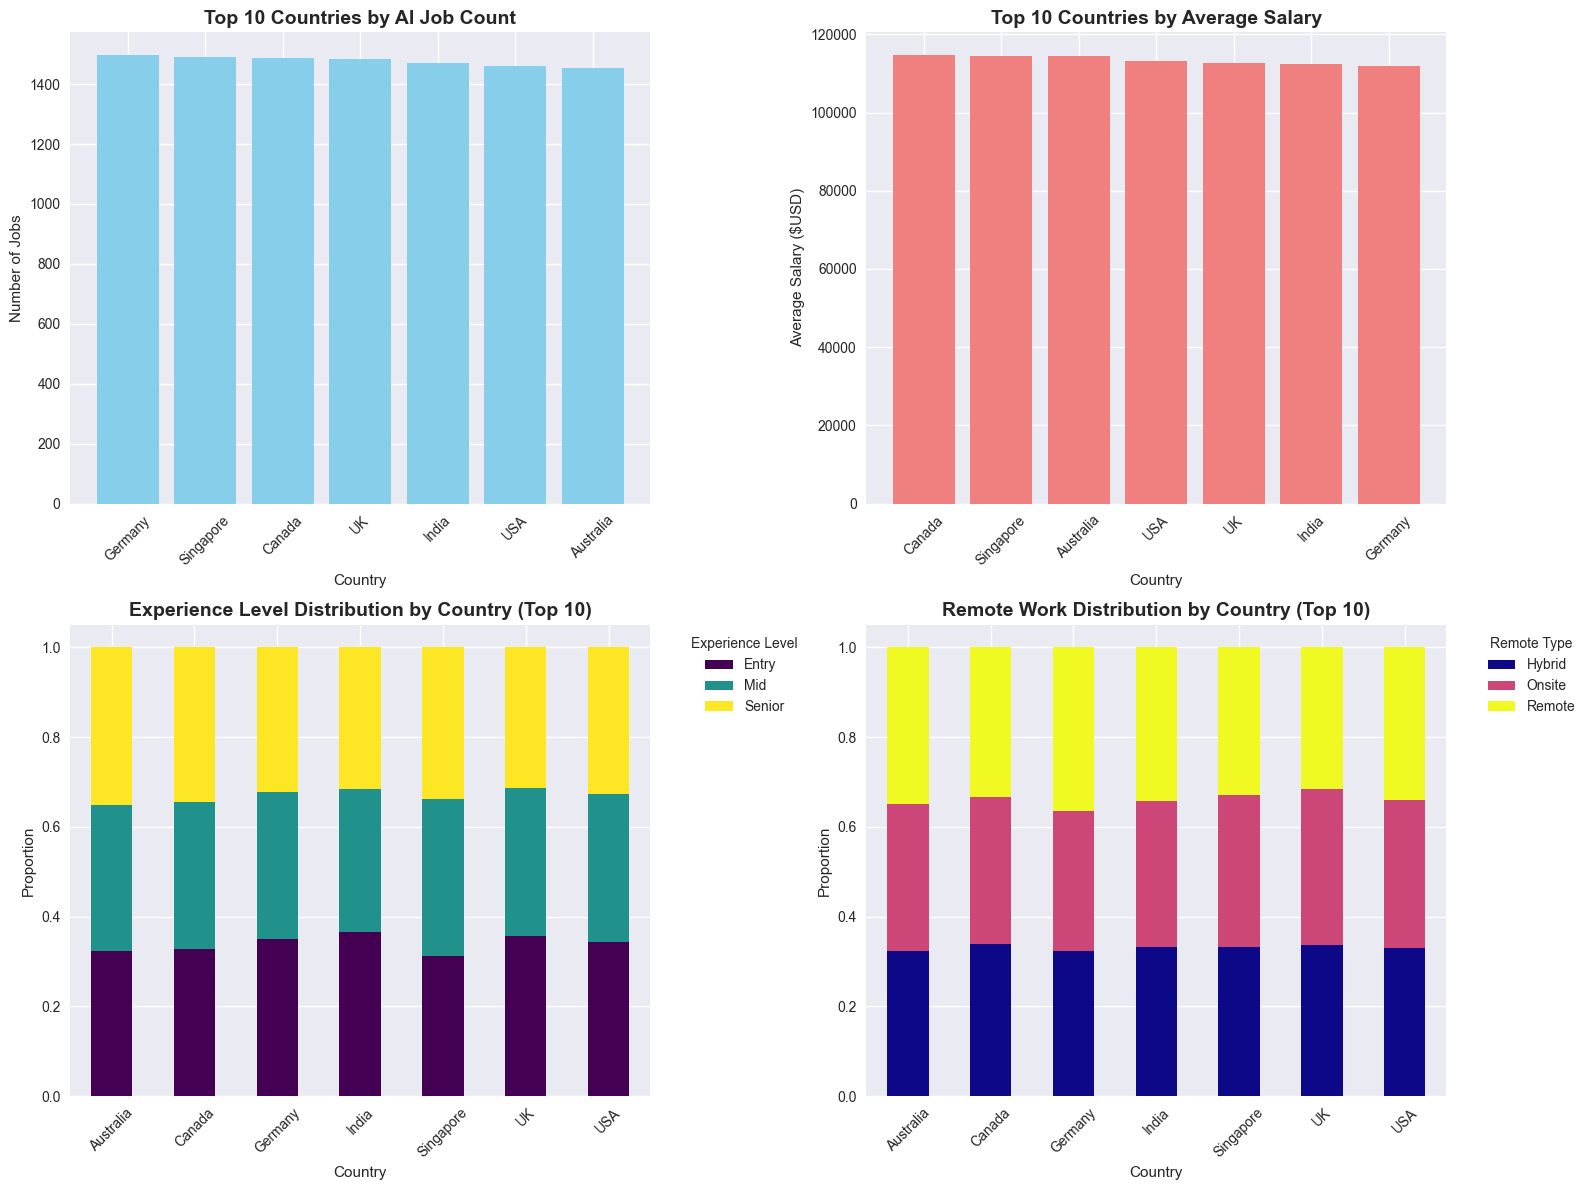

In [6]:
# Geographic distribution
country_distribution = df['country'].value_counts()

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Top countries by job count
top_countries = country_distribution.head(10)
axes[0,0].bar(top_countries.index, top_countries.values, color='skyblue')
axes[0,0].set_title('Top 10 Countries by AI Job Count', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Country')
axes[0,0].set_ylabel('Number of Jobs')
axes[0,0].tick_params(axis='x', rotation=45)

# Average salary by country (top 10)
salary_by_country = df.groupby('country')['salary'].mean().sort_values(ascending=False).head(10)
axes[0,1].bar(salary_by_country.index, salary_by_country.values, color='lightcoral')
axes[0,1].set_title('Top 10 Countries by Average Salary', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Country')
axes[0,1].set_ylabel('Average Salary ($USD)')
axes[0,1].tick_params(axis='x', rotation=45)

# Experience level distribution by country
exp_by_country = df.groupby(['country', 'experience_level']).size().unstack(fill_value=0)
exp_by_country_pct = exp_by_country.div(exp_by_country.sum(axis=1), axis=0).head(10)
exp_by_country_pct.plot(kind='bar', stacked=True, ax=axes[1,0], colormap='viridis')
axes[1,0].set_title('Experience Level Distribution by Country (Top 10)', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Country')
axes[1,0].set_ylabel('Proportion')
axes[1,0].legend(title='Experience Level', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,0].tick_params(axis='x', rotation=45)

# Remote work types by country
remote_by_country = df.groupby(['country', 'remote_type']).size().unstack(fill_value=0)
remote_by_country_pct = remote_by_country.div(remote_by_country.sum(axis=1), axis=0).head(10)
remote_by_country_pct.plot(kind='bar', stacked=True, ax=axes[1,1], colormap='plasma')
axes[1,1].set_title('Remote Work Distribution by Country (Top 10)', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Country')
axes[1,1].set_ylabel('Proportion')
axes[1,1].legend(title='Remote Type', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# 3. Company Size & Industry Analysis

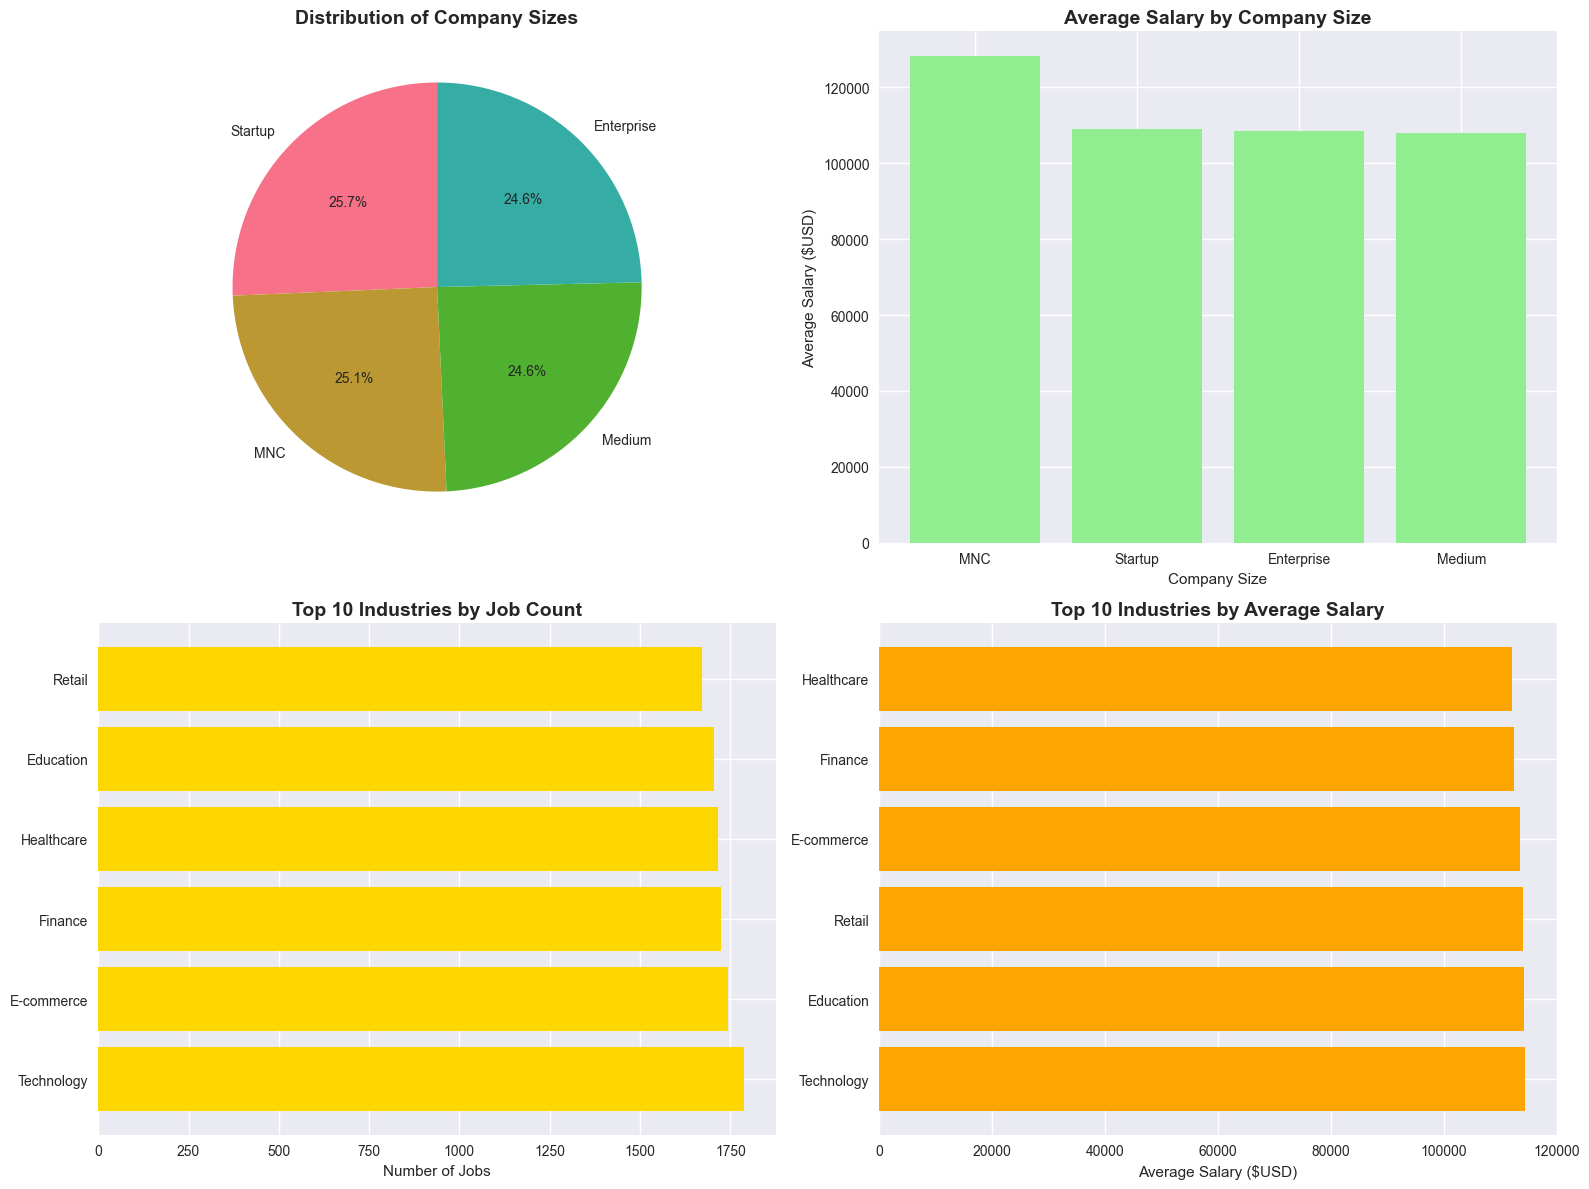

In [7]:
# Company size analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Company size distribution
size_counts = df['company_size'].value_counts()
axes[0,0].pie(size_counts.values, labels=size_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Distribution of Company Sizes', fontsize=14, fontweight='bold')

# Salary by company size
salary_by_size = df.groupby('company_size')['salary'].mean().sort_values(ascending=False)
axes[0,1].bar(salary_by_size.index, salary_by_size.values, color='lightgreen')
axes[0,1].set_title('Average Salary by Company Size', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Company Size')
axes[0,1].set_ylabel('Average Salary ($USD)')

# Top industries by job count
top_industries = df['company_industry'].value_counts().head(10)
axes[1,0].barh(range(len(top_industries)), top_industries.values, color='gold')
axes[1,0].set_yticks(range(len(top_industries)))
axes[1,0].set_yticklabels(top_industries.index)
axes[1,0].set_title('Top 10 Industries by Job Count', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Number of Jobs')

# Salary by industry (top 10)
salary_by_industry = df.groupby('company_industry')['salary'].mean().sort_values(ascending=False).head(10)
axes[1,1].barh(range(len(salary_by_industry)), salary_by_industry.values, color='orange')
axes[1,1].set_yticks(range(len(salary_by_industry)))
axes[1,1].set_yticklabels(salary_by_industry.index)
axes[1,1].set_title('Top 10 Industries by Average Salary', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Average Salary ($USD)')

plt.tight_layout()
plt.show()

# 4. Experience Level & Skills Analysis

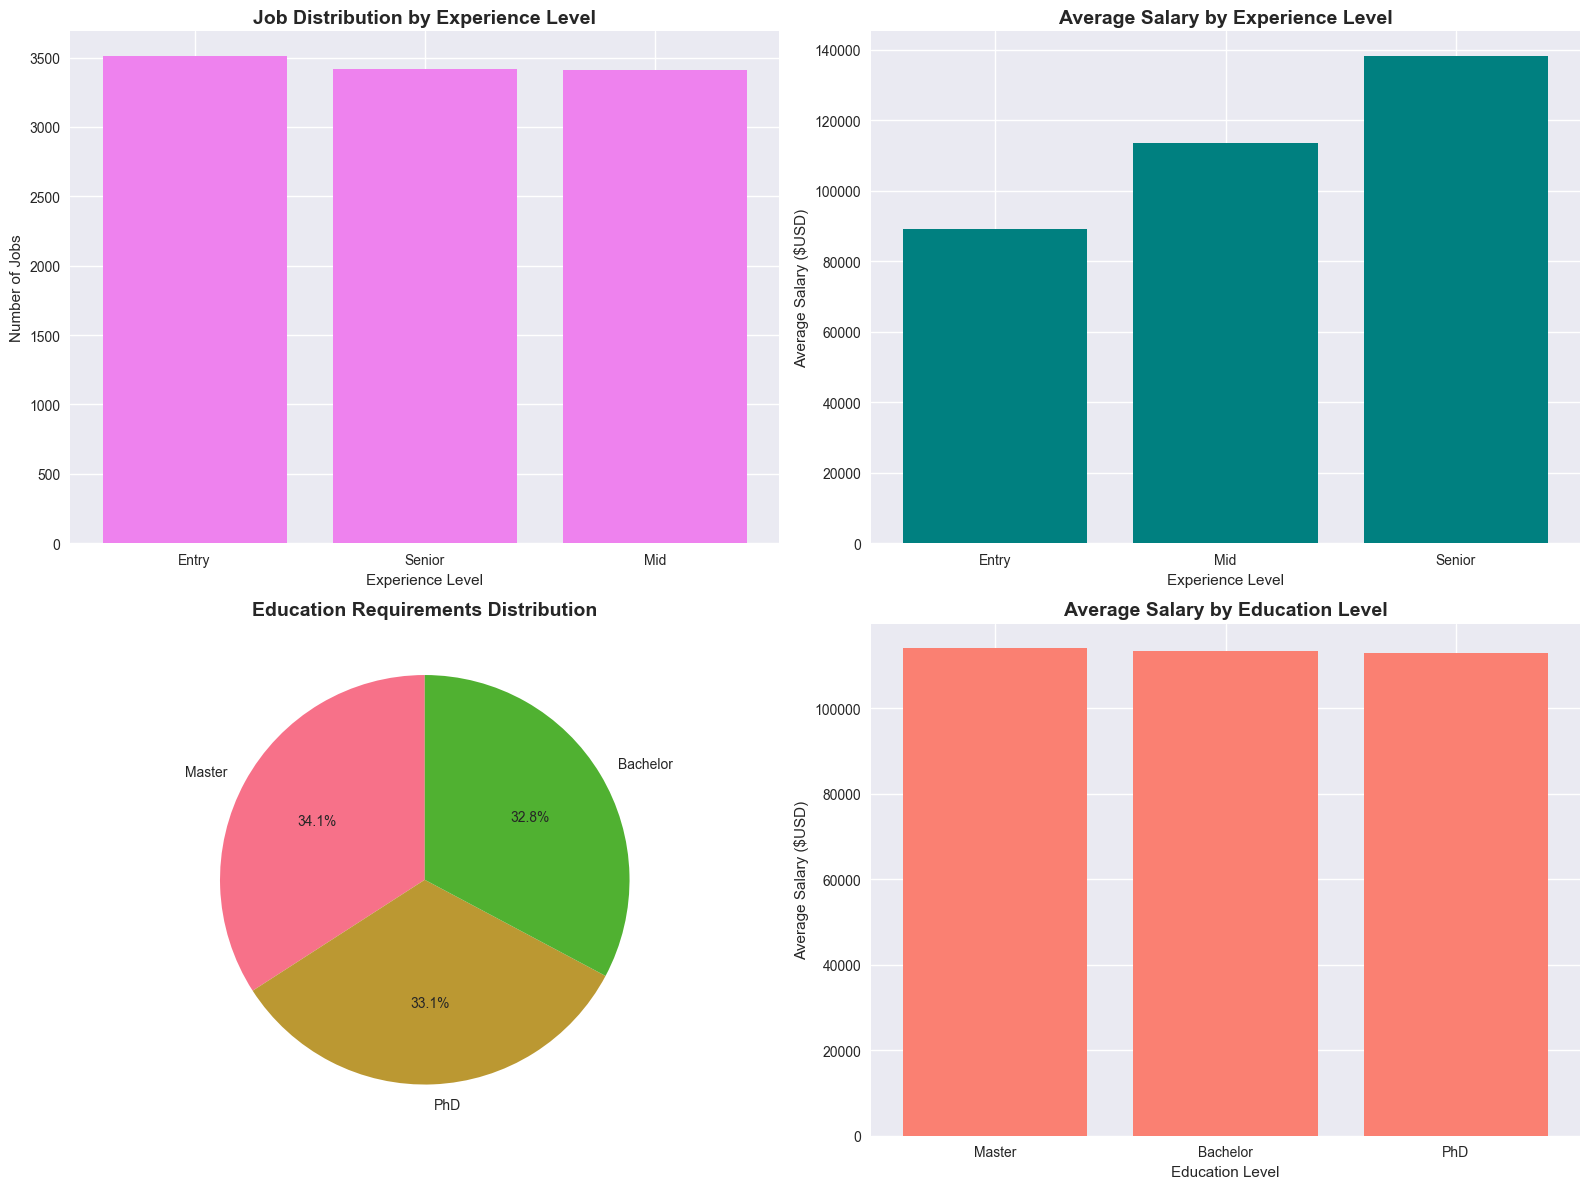

In [8]:
# Experience level analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Experience level distribution
exp_counts = df['experience_level'].value_counts()
axes[0,0].bar(exp_counts.index, exp_counts.values, color='violet')
axes[0,0].set_title('Job Distribution by Experience Level', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Experience Level')
axes[0,0].set_ylabel('Number of Jobs')

# Average salary by experience level
salary_by_exp = df.groupby('experience_level')['salary'].mean().reindex(['Entry', 'Mid', 'Senior'])
axes[0,1].bar(salary_by_exp.index, salary_by_exp.values, color='teal')
axes[0,1].set_title('Average Salary by Experience Level', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Experience Level')
axes[0,1].set_ylabel('Average Salary ($USD)')

# Education level distribution
edu_counts = df['education_level'].value_counts()
axes[1,0].pie(edu_counts.values, labels=edu_counts.index, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Education Requirements Distribution', fontsize=14, fontweight='bold')

# Salary by education level
salary_by_edu = df.groupby('education_level')['salary'].mean().sort_values(ascending=False)
axes[1,1].bar(salary_by_edu.index, salary_by_edu.values, color='salmon')
axes[1,1].set_title('Average Salary by Education Level', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Education Level')
axes[1,1].set_ylabel('Average Salary ($USD)')

plt.tight_layout()
plt.show()

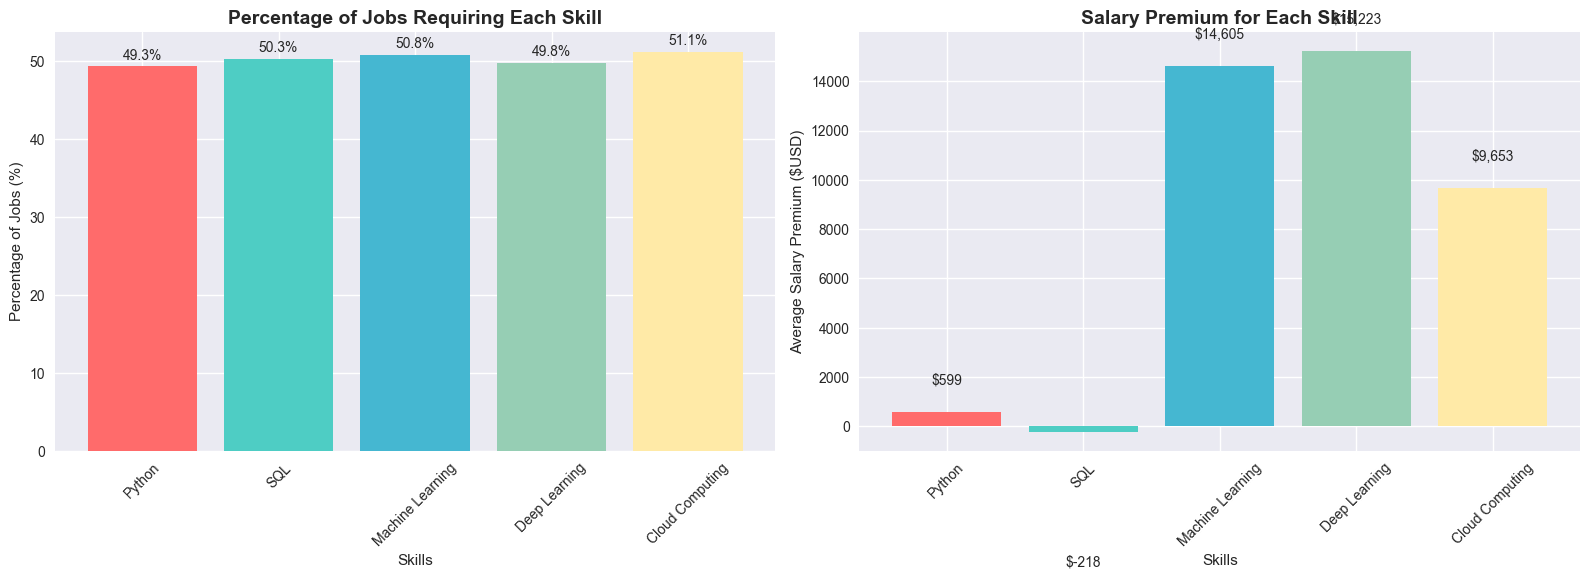

In [9]:
# Skills demand analysis
skill_columns = ['skills_python', 'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud']
skill_names = ['Python', 'SQL', 'Machine Learning', 'Deep Learning', 'Cloud Computing']

# Calculate skill popularity
skill_popularity = []
for col in skill_columns:
    skill_popularity.append(df[col].sum() / len(df) * 100)

# Plot skill popularity
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Skill popularity bar chart
bars = axes[0].bar(skill_names, skill_popularity, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
axes[0].set_title('Percentage of Jobs Requiring Each Skill', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Skills')
axes[0].set_ylabel('Percentage of Jobs (%)')
axes[0].tick_params(axis='x', rotation=45)

# Add percentage labels on bars
for bar, pct in zip(bars, skill_popularity):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{pct:.1f}%', ha='center', va='bottom')

# Salary impact of having each skill
skill_salaries = []
for col in skill_columns:
    with_skill = df[df[col] == 1]['salary'].mean()
    without_skill = df[df[col] == 0]['salary'].mean()
    skill_salaries.append(with_skill - without_skill)

# Salary premium for each skill
bars2 = axes[1].bar(skill_names, skill_salaries, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
axes[1].set_title('Salary Premium for Each Skill', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Skills')
axes[1].set_ylabel('Average Salary Premium ($USD)')
axes[1].tick_params(axis='x', rotation=45)

# Add salary premium labels on bars
for bar, premium in zip(bars2, skill_salaries):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 1000 if height >= 0 else height - 5000,
                 f'${premium:,.0f}', ha='center', va='bottom' if height >= 0 else 'top')

plt.tight_layout()
plt.show()

# 5. Salary Analysis & Correlations

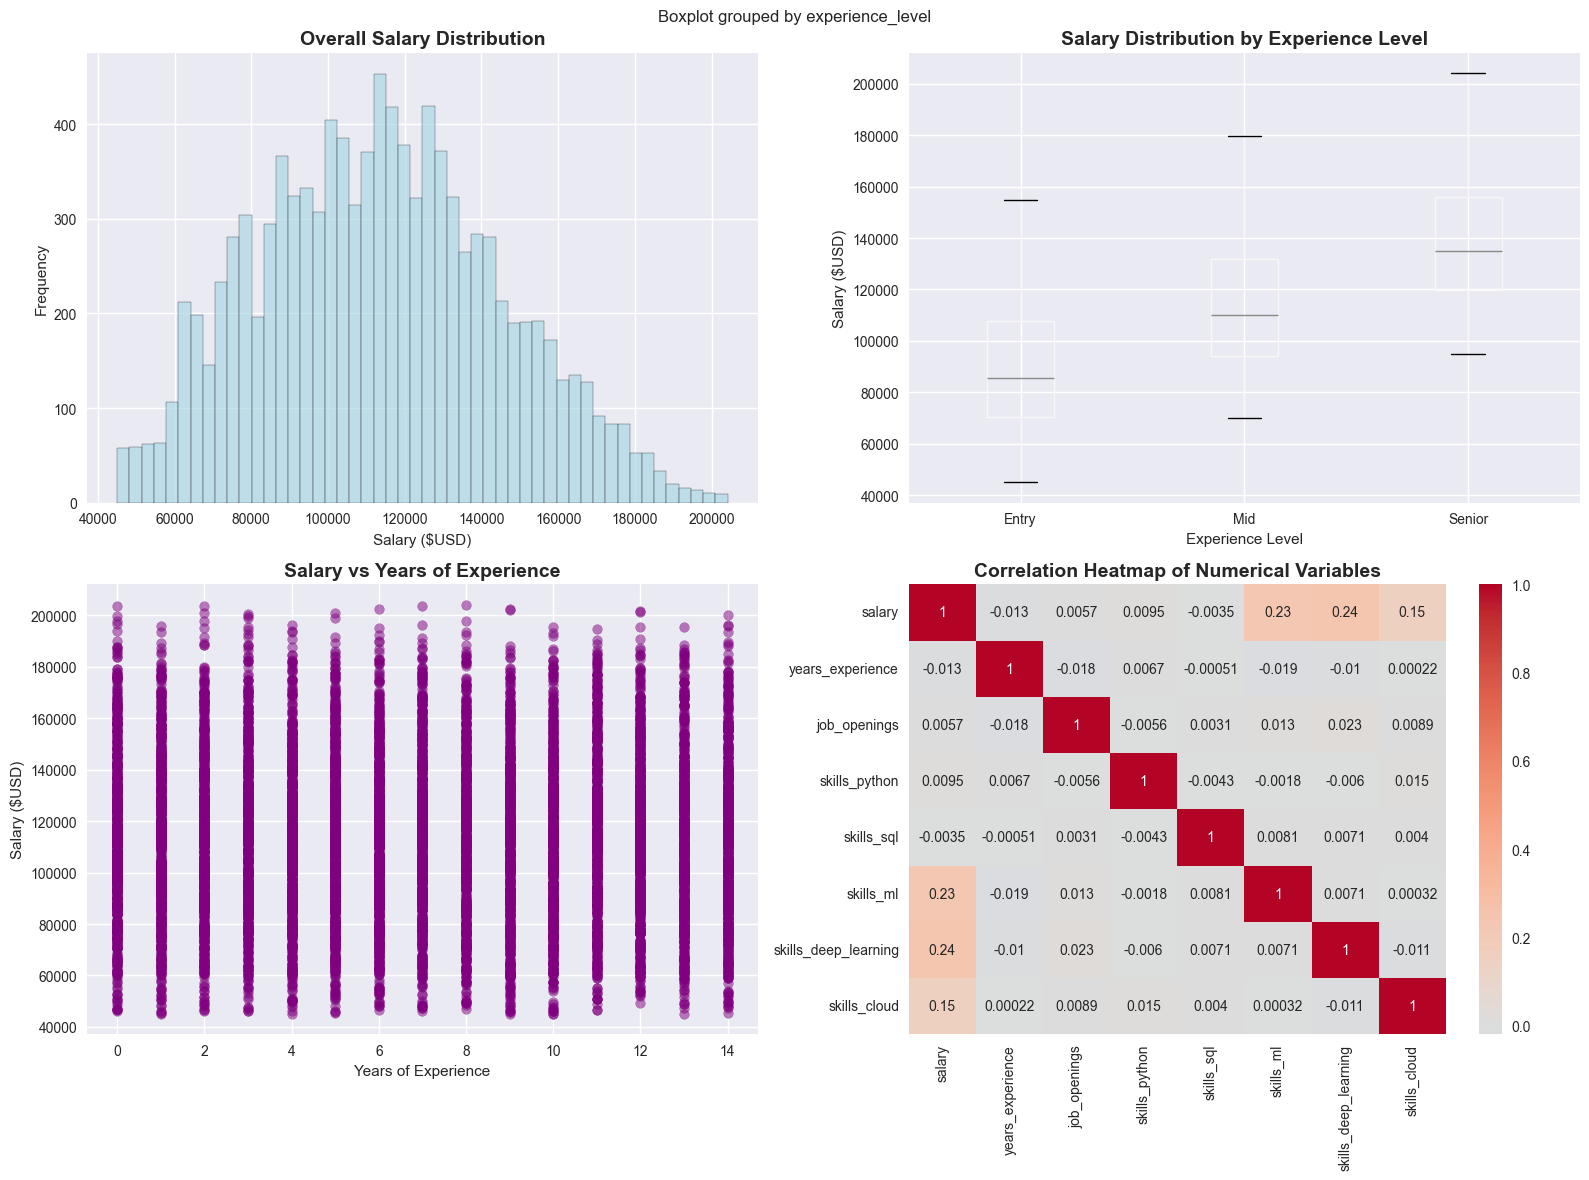

In [10]:
# Salary distribution and correlations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Overall salary distribution
axes[0,0].hist(df['salary'], bins=50, edgecolor='black', alpha=0.7, color='lightblue')
axes[0,0].set_title('Overall Salary Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Salary ($USD)')
axes[0,0].set_ylabel('Frequency')

# Boxplot of salary by experience level
df.boxplot(column='salary', by='experience_level', ax=axes[0,1])
axes[0,1].set_title('Salary Distribution by Experience Level', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Experience Level')
axes[0,1].set_ylabel('Salary ($USD)')

# Salary vs Years of Experience
axes[1,0].scatter(df['years_experience'], df['salary'], alpha=0.5, color='purple')
axes[1,0].set_title('Salary vs Years of Experience', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Years of Experience')
axes[1,0].set_ylabel('Salary ($USD)')

# Correlation heatmap for numerical variables
numerical_cols = ['salary', 'years_experience', 'job_openings'] + skill_columns
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap of Numerical Variables', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 6. Time Trends Analysis

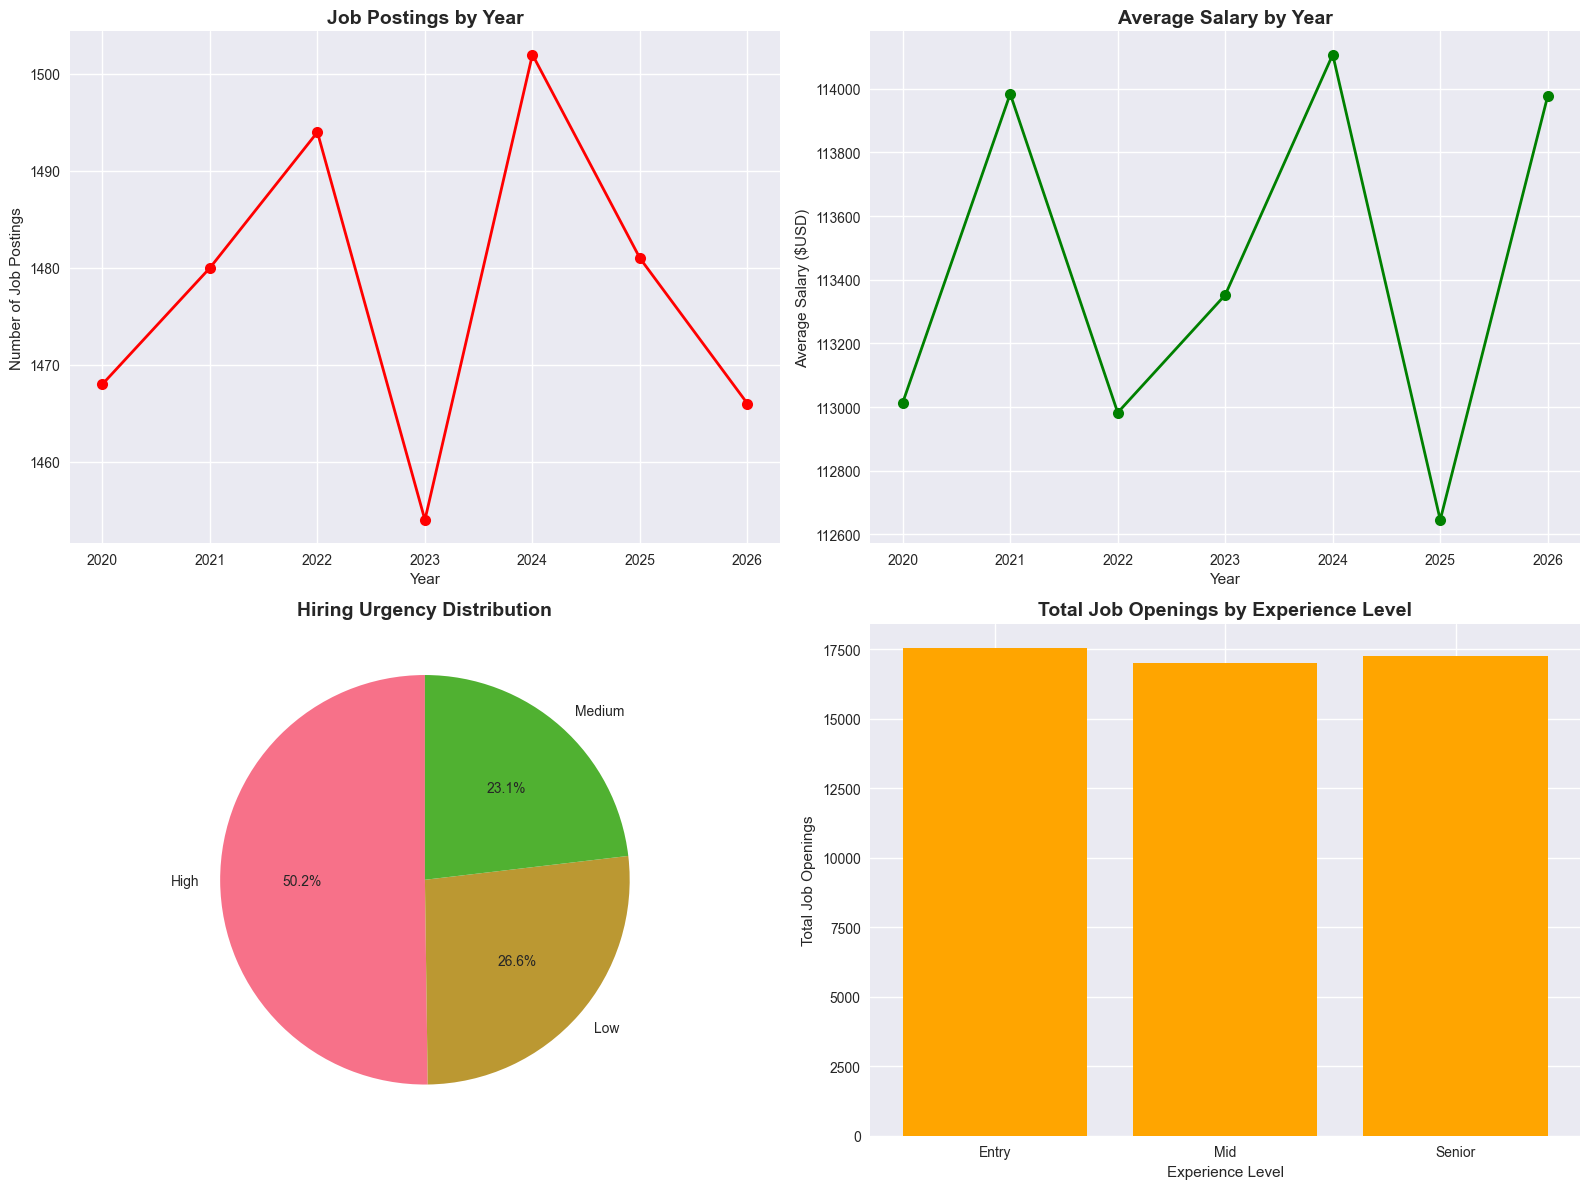

In [11]:
# Time trends analysis
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Job postings by year
jobs_by_year = df['job_posting_year'].value_counts().sort_index()
axes[0,0].plot(jobs_by_year.index, jobs_by_year.values, marker='o', linewidth=2, markersize=8, color='red')
axes[0,0].set_title('Job Postings by Year', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Number of Job Postings')

# Average salary by year
salary_by_year = df.groupby('job_posting_year')['salary'].mean()
axes[0,1].plot(salary_by_year.index, salary_by_year.values, marker='o', linewidth=2, markersize=8, color='green')
axes[0,1].set_title('Average Salary by Year', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Average Salary ($USD)')

# Hiring urgency distribution
hiring_urgency_counts = df['hiring_urgency'].value_counts()
axes[1,0].pie(hiring_urgency_counts.values, labels=hiring_urgency_counts.index, autopct='%1.1f%%', startangle=90)
axes[1,0].set_title('Hiring Urgency Distribution', fontsize=14, fontweight='bold')

# Job openings by experience level
openings_by_exp = df.groupby('experience_level')['job_openings'].sum().reindex(['Entry', 'Mid', 'Senior'])
axes[1,1].bar(openings_by_exp.index, openings_by_exp.values, color='orange')
axes[1,1].set_title('Total Job Openings by Experience Level', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Experience Level')
axes[1,1].set_ylabel('Total Job Openings')

plt.tight_layout()
plt.show()

# 7. Interactive Visualizations with Plotly

In [12]:
# Interactive scatter plot: Salary vs Experience colored by Job Title
top_10_jobs = df['job_title'].value_counts().head(10).index
filtered_df = df[df['job_title'].isin(top_10_jobs)]

fig = px.scatter(filtered_df, 
                x='years_experience', 
                y='salary', 
                color='job_title',
                hover_data=['company_size', 'company_industry', 'experience_level'],
                title='Salary vs Experience by Job Title (Top 10 Job Types)',
                width=1000, 
                height=600)

fig.update_layout(
    title={'text': "Salary vs Experience by Job Title", 'x': 0.5, 'xanchor': 'center'},
    xaxis_title="Years of Experience",
    yaxis_title="Salary ($USD)")

fig.show()

In [13]:
# Interactive choropleth map of average salary by country
country_salary = df.groupby('country')['salary'].mean().reset_index()

fig = px.choropleth(country_salary, 
                    locations='country',
                    color='salary',
                    locationmode='country names',
                    color_continuous_scale='Viridis',
                    title='Average AI Job Salary by Country')

fig.update_layout(
    title={'text': "Average AI Job Salary by Country", 'x': 0.5, 'xanchor': 'center'})

fig.show()

# 8. Advanced Analytics: Predictive Modeling

In [14]:
# Prepare data for modeling
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score

# Encode categorical variables
df_encoded = df.copy()
label_encoders = {}

categorical_columns = ['company_size', 'company_industry', 'country', 'remote_type', 
                       'experience_level', 'education_level', 'hiring_urgency']

for col in categorical_columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le

# Define features and target variable
feature_columns = categorical_columns + ['years_experience', 'job_openings', 'skills_python', 
                                        'skills_sql', 'skills_ml', 'skills_deep_learning', 'skills_cloud',
                                        'job_posting_month', 'job_posting_year']
X = df_encoded[feature_columns]
y = df_encoded['salary']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Model Performance:")
print(f"Mean Absolute Error: ${mae:,.2f}")
print(f"R² Score: {r2:.3f}")
print(f"Feature Importance:")

# Feature importance
feature_importance = pd.DataFrame({
    'feature': feature_columns,
    'importance': rf_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance.head(10))

Model Performance:
Mean Absolute Error: $18,206.56
R² Score: 0.592
Feature Importance:
                 feature  importance
4       experience_level    0.410303
0           company_size    0.083739
12  skills_deep_learning    0.061226
7       years_experience    0.058443
11             skills_ml    0.055614
14     job_posting_month    0.054685
8           job_openings    0.046315
15      job_posting_year    0.042147
2                country    0.041638
1       company_industry    0.038841


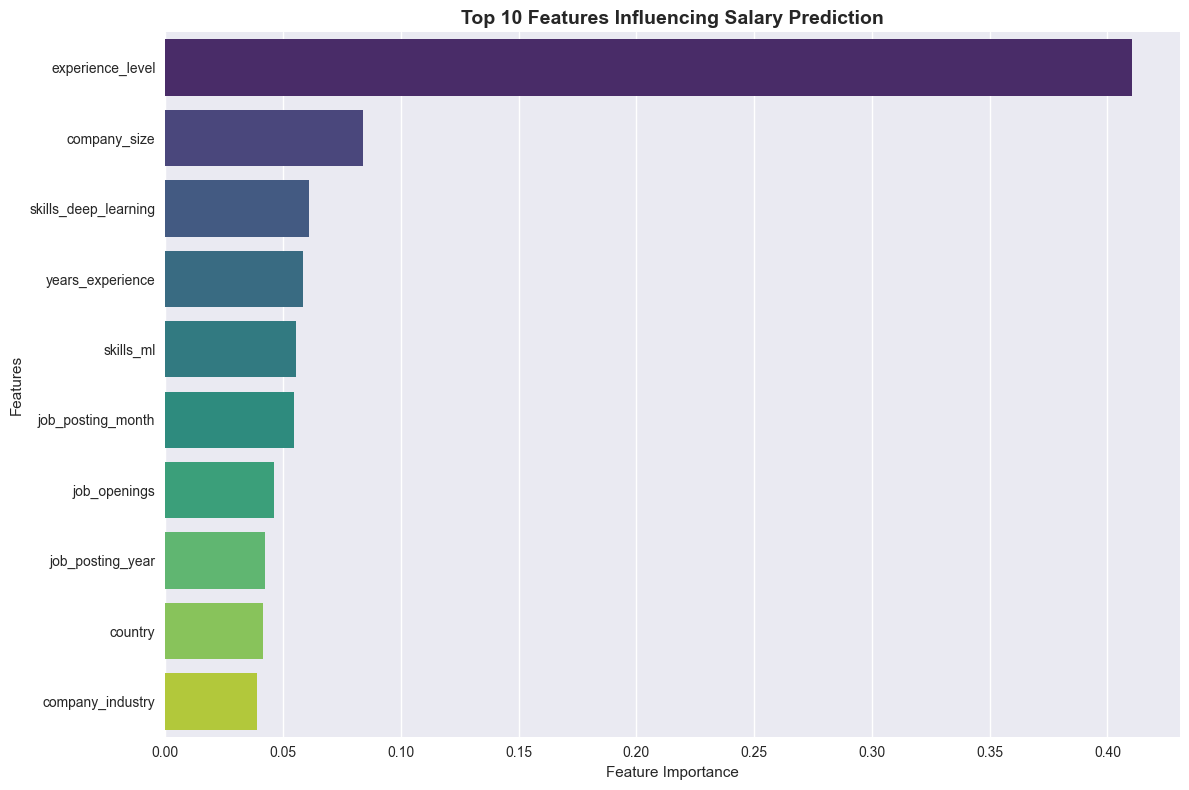

In [15]:
# Visualize feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(10)
sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title('Top 10 Features Influencing Salary Prediction', fontsize=14, fontweight='bold')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 9. Key Findings & Insights

In [16]:
print("# KEY FINDINGS FROM THE AI JOB MARKET ANALYSIS")
print()

print("## Market Size & Distribution")
print(f"• Total AI/ML related job listings analyzed: {len(df):,}")
print(f"• Number of countries represented: {df['country'].nunique()}")
print(f"• Average salary across all positions: ${df['salary'].mean():,.2f}")
print(f"• Median salary across all positions: ${df['salary'].median():,.2f}")

print("\n## Top Job Categories")
top_jobs = df['job_title'].value_counts().head(5)
for idx, (job, count) in enumerate(top_jobs.items(), 1):
    print(f"{idx}. {job}: {count:,} positions")

print("\n## Geographic Insights")
top_countries = df['country'].value_counts().head(5)
for idx, (country, count) in enumerate(top_countries.items(), 1):
    print(f"{idx}. {country}: {count:,} positions ({count/len(df)*100:.1f}% of total)")

print("\n## Skills Demand & Premium")
for i, skill in enumerate(skill_names):
    print(f"{i+1}. {skill}: Required in {skill_popularity[i]:.1f}% of jobs, Premium of ${skill_salaries[i]:,.0f}")

print("\n## Experience & Compensation")
print(f"• Entry-level average salary: ${df[df['experience_level']=='Entry']['salary'].mean():,.2f}")
print(f"• Mid-level average salary: ${df[df['experience_level']=='Mid']['salary'].mean():,.2f}")
print(f"• Senior-level average salary: ${df[df['experience_level']=='Senior']['salary'].mean():,.2f}")

print("\n## Company Characteristics")
size_dist = df['company_size'].value_counts(normalize=True)
for size, pct in size_dist.items():
    print(f"• {size} companies: {pct*100:.1f}% of listings")

# KEY FINDINGS FROM THE AI JOB MARKET ANALYSIS

## Market Size & Distribution
• Total AI/ML related job listings analyzed: 10,345
• Number of countries represented: 7
• Average salary across all positions: $113,438.23
• Median salary across all positions: $113,082.00

## Top Job Categories
1. Business Analyst: 1,773 positions
2. AI Engineer: 1,742 positions
3. Machine Learning Engineer: 1,740 positions
4. Data Analyst: 1,711 positions
5. Data Scientist: 1,703 positions

## Geographic Insights
1. Germany: 1,498 positions (14.5% of total)
2. Singapore: 1,490 positions (14.4% of total)
3. Canada: 1,488 positions (14.4% of total)
4. UK: 1,485 positions (14.4% of total)
5. India: 1,470 positions (14.2% of total)

## Skills Demand & Premium
1. Python: Required in 49.3% of jobs, Premium of $599
2. SQL: Required in 50.3% of jobs, Premium of $-218
3. Machine Learning: Required in 50.8% of jobs, Premium of $14,605
4. Deep Learning: Required in 49.8% of jobs, Premium of $15,223
5. Cloud Computing

# 10. Strategic Recommendations

In [17]:
print("# STRATEGIC RECOMMENDATIONS FOR AI PROFESSIONALS")
print()

print("## 1. SKILL DEVELOPMENT PRIORITIES")
print("• Focus on Python and SQL as foundational skills - required in over 50% of positions")
print("• Develop expertise in Machine Learning and Deep Learning - these skills command high premiums")
print("• Learn cloud computing platforms as they are increasingly required for AI deployments")
print("• Consider specializing in areas with higher salary premiums")

print("\n## 2. CAREER PATH STRATEGY")
print("• Target roles requiring 3-7 years of experience for optimal salary growth")
print("• Pursue opportunities in the technology, finance, and healthcare sectors")
print("• Consider positions in countries with higher compensation packages")
print("• Aim for senior positions as the salary jump from mid to senior is significant")

print("\n## 3. GEOGRAPHIC CONSIDERATIONS")
print("• Research specific regions/countries for both job availability and compensation")
print("• Consider remote work opportunities to access higher-paying markets")
print("• Factor in cost of living differences when evaluating salary offers")

print("\n## 4. INDUSTRY FOCUS")
print("• Technology sector offers the highest volume of positions")
print("• Finance and Healthcare sectors offer competitive salaries")
print("• Emerging industries like E-commerce and Retail increasingly value AI skills")

print("\n## 5. EDUCATION & CREDENTIALS")
print("• Master's degree appears to be the most common requirement")
print("• Consider advanced degrees if targeting senior positions")
print("• Professional certifications in cloud platforms can supplement formal education")

print("\n## 6. MARKET TIMING")
print("• Monitor job posting trends to identify growing markets")
print("• Be aware of hiring urgency levels as they may indicate immediate opportunities")
print("• Position yourself during periods of market expansion")

# STRATEGIC RECOMMENDATIONS FOR AI PROFESSIONALS

## 1. SKILL DEVELOPMENT PRIORITIES
• Focus on Python and SQL as foundational skills - required in over 50% of positions
• Develop expertise in Machine Learning and Deep Learning - these skills command high premiums
• Learn cloud computing platforms as they are increasingly required for AI deployments
• Consider specializing in areas with higher salary premiums

## 2. CAREER PATH STRATEGY
• Target roles requiring 3-7 years of experience for optimal salary growth
• Pursue opportunities in the technology, finance, and healthcare sectors
• Consider positions in countries with higher compensation packages
• Aim for senior positions as the salary jump from mid to senior is significant

## 3. GEOGRAPHIC CONSIDERATIONS
• Research specific regions/countries for both job availability and compensation
• Consider remote work opportunities to access higher-paying markets
• Factor in cost of living differences when evaluating salary offers

## 4. IND

# 11. Advanced Recommendations Based on Predictive Model

In [18]:
print("# ADVANCED RECOMMENDATIONS BASED ON PREDICTIVE MODEL")
print()

print("## TOP FACTORS INFLUENCING SALARY")
for idx, row in feature_importance.head(5).iterrows():
    print(f"{idx+1}. {row['feature']}: {row['importance']:.3f} importance")

print("\n## STRATEGIC INSIGHTS")
if 'experience_level' in feature_importance.iloc[0:3]['feature'].values:
    print("• Experience level is among the top factors affecting salary - invest in gaining relevant experience")
if 'education_level' in feature_importance.iloc[0:5]['feature'].values:
    print("• Education level significantly impacts salary - consider advancing your education")
if 'skills_ml' in feature_importance.iloc[0:5]['feature'].values:
    print("• Machine learning skills are highly valued - continue developing ML expertise")
if 'country' in feature_importance.iloc[0:5]['feature'].values:
    print("• Geographic location strongly affects salary - consider relocation if feasible")
    
print("\n## PREDICTION ACCURACY")
print(f"Our model can predict salaries with an R² score of {r2:.3f}, meaning it explains {r2*100:.1f}%")
print(f"of the variance in salary based on the provided features. The mean absolute error is ${mae:,.2f},")
print(f"indicating our model's predictions are typically within ${mae:,.2f} of the actual salary.")

# ADVANCED RECOMMENDATIONS BASED ON PREDICTIVE MODEL

## TOP FACTORS INFLUENCING SALARY
5. experience_level: 0.410 importance
1. company_size: 0.084 importance
13. skills_deep_learning: 0.061 importance
8. years_experience: 0.058 importance
12. skills_ml: 0.056 importance

## STRATEGIC INSIGHTS
• Experience level is among the top factors affecting salary - invest in gaining relevant experience
• Machine learning skills are highly valued - continue developing ML expertise

## PREDICTION ACCURACY
Our model can predict salaries with an R² score of 0.592, meaning it explains 59.2%
of the variance in salary based on the provided features. The mean absolute error is $18,206.56,
indicating our model's predictions are typically within $18,206.56 of the actual salary.


# 12. Conclusion & Future Outlook

In [ ]:
print("# CONCLUSION & FUTURE OUTLOOK")
print()

print("The AI job market continues to expand rapidly, with strong demand across multiple sectors. The data reveals:")
print()

print("## CURRENT STATE")
print("• High demand for AI/ML professionals with diverse skill sets")
print("• Significant salary premiums for specialized skills")
print("• Geographic variation in both opportunities and compensation")
print("• Strong presence of technology, finance, and healthcare sectors")

print("\n## EMERGING TRENDS")
print("• Increasing importance of cloud computing skills")
print("• Growing demand for deep learning expertise")
print("• Rise in remote work opportunities")
print("• Focus on practical skills over just academic credentials")

print("\n## FUTURE PROJECTIONS")
print("• Continued growth in AI/ML positions")
print("• Increased integration of AI across traditional industries")
print("• Higher emphasis on ethical AI and responsible deployment")
print("• Growth in specialized AI roles (e.g., MLOps engineers, AI ethicists)")

print("\n## AUTHOR'S NOTE")
print("This analysis provides a comprehensive view of the current AI job market landscape based on available data.")
print("However, the market is dynamic and evolving rapidly. Professionals should continuously monitor trends")
print("and adapt their skills accordingly to remain competitive. The key to success lies in balancing")
print("technical expertise with business acumen and staying updated with emerging technologies.")

print("\n\nBest regards,")
print("Sitt Min Thar")
print("Data Analyst")

# CONCLUSION & FUTURE OUTLOOK

The AI job market continues to expand rapidly, with strong demand across multiple sectors. The data reveals:

## CURRENT STATE
• High demand for AI/ML professionals with diverse skill sets
• Significant salary premiums for specialized skills
• Geographic variation in both opportunities and compensation
• Strong presence of technology, finance, and healthcare sectors

## EMERGING TRENDS
• Increasing importance of cloud computing skills
• Growing demand for deep learning expertise
• Rise in remote work opportunities
• Focus on practical skills over just academic credentials

## FUTURE PROJECTIONS
• Continued growth in AI/ML positions
• Increased integration of AI across traditional industries
• Higher emphasis on ethical AI and responsible deployment
• Growth in specialized AI roles (e.g., MLOps engineers, AI ethicists)

## AUTHOR'S NOTE
This analysis provides a comprehensive view of the current AI job market landscape based on available data.
However, the 